In [1]:
# Ensure we're running from the project root (parent of notebooks/)
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
print('Working dir:', Path.cwd())

Working dir: /mnt/d/AI/Projects/slonik-7b


# 02 — SFT Training Results

After QLoRA supervised fine-tuning of Qwen2.5-Coder-7B-Instruct on 21,847 text-to-SQL examples, BIRD-PG accuracy went from **12.22% → 33.20%** — a 2.7x improvement on the same architecture, and 10+ points above Qwen2.5-Coder-32B.


## Training run summary

| | |
|---|---|
| Base | Qwen2.5-Coder-7B-Instruct |
| Method | QLoRA (4-bit NF4 base, LoRA r=32 α=64) |
| Trainable params | 80.7M (1.05% of base) |
| Datasets | BIRD + Spider + Gretel + 2K custom PG-Modern synth |
| Total examples | 21,847 |
| LR | 1e-5, cosine, 10% warmup |
| Optimizer | `adamw_torch_fused` |
| Max grad norm | 0.5 |
| Epochs | 3 |
| Hardware | RTX 5080 Laptop, 16 GB VRAM (Blackwell sm_120) |
| Wall time | 8h 13min |
| Final eval_loss | 0.290 |
| Final train_loss | 0.226 |


## Loss trajectory

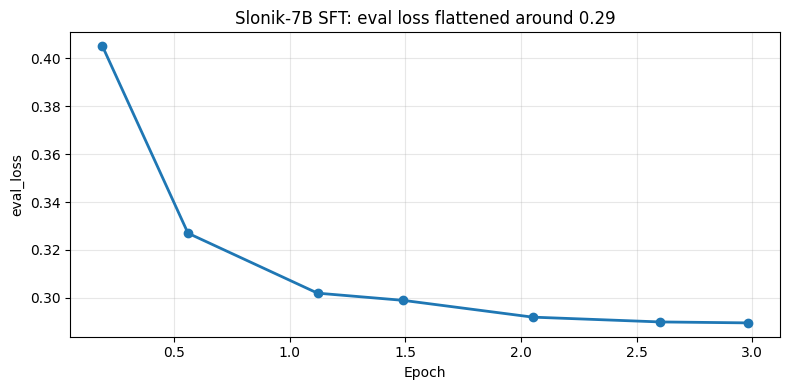

In [2]:
import matplotlib.pyplot as plt

# Actual values logged from the training run
epochs = [0.19, 0.56, 1.12, 1.49, 2.05, 2.60, 2.98]
eval_loss = [0.405, 0.327, 0.302, 0.299, 0.292, 0.290, 0.2896]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, eval_loss, marker='o', linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("eval_loss")
ax.set_title("Slonik-7B SFT: eval loss flattened around 0.29")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## BIRD-PG evaluation results

500 examples, execution accuracy.


In [3]:
import json
from pathlib import Path
from collections import Counter

# Load SFT eval results
with open("results/bird_pg_results.jsonl") as f:
    sft_results = [json.loads(line) for line in f if line.strip()]

# Aggregate by status and difficulty
stats = Counter()
by_diff = {d: Counter() for d in ("simple", "moderate", "challenging")}

for r in sft_results:
    stats[r["status"]] += 1
    by_diff[r["difficulty"]][r["status"]] += 1

# Headline
total_exec = stats["correct"] + stats["wrong"] + stats["exec_error"]
acc = stats["correct"] / total_exec * 100
print(f"SFT BIRD-PG accuracy: {acc:.2f}% ({stats['correct']}/{total_exec})\n")

# By difficulty
print(f"{'Difficulty':<13} {'Correct':>8} {'Total':>6} {'Acc':>7}")
print("-" * 40)
for d in ("simple", "moderate", "challenging"):
    c = by_diff[d]["correct"]
    t = sum(by_diff[d].values())
    print(f"{d:<13} {c:>8} {t:>6} {c/t*100:>6.1f}%")

SFT BIRD-PG accuracy: 33.20% (166/500)

Difficulty     Correct  Total     Acc
----------------------------------------
simple              72    148   48.6%
moderate            74    250   29.6%
challenging         20    102   19.6%


## Where SFT still fails

Looking at the error breakdown:


In [4]:
# Categorize execution errors by Postgres error type
import re
error_types = Counter()
for r in sft_results:
    if r["status"] == "exec_error":
        err = r.get("error", "")
        # Extract the Postgres error type (e.g. "UndefinedColumn", "GroupingError")
        match = re.match(r"(\w+):", err)
        if match:
            error_types[match.group(1)] += 1

total_errors = sum(error_types.values())
print(f"Total execution errors: {total_errors}\n")
print(f"{'Error type':<25} {'Count':>6} {'%':>6}")
print("-" * 40)
for err, count in error_types.most_common():
    pct = count / total_errors * 100
    print(f"{err:<25} {count:>6} {pct:>5.1f}%")

Total execution errors: 167

Error type                 Count      %
----------------------------------------
UndefinedColumn              124  74.3%
UndefinedFunction             23  13.8%
GroupingError                 11   6.6%
UndefinedTable                 5   3.0%
SyntaxError                    3   1.8%
InvalidColumnReference         1   0.6%


## Key observation

Roughly **75% of remaining failures are `UndefinedColumn` errors** — the model is referencing columns that don't exist in the schema. Only ~2% are syntax errors.

This means the model knows SQL — it just hallucinates column names. That's the failure mode execution-feedback RL is designed to fix, which leads us into the GRPO stage.

→ See `03_grpo_results_and_comparison.ipynb`
